# 01 — Hypothesis Testing, Confidence Intervals & Effect Sizes (§5.1 + §5.2)

**Objective:** Apply formal statistical methods to test 5 hypotheses about the Airbnb marketplace. For each test: state hypotheses, check assumptions, select appropriate test, report test statistic/p-value/effect size, and interpret in business terms.

**Key principle:** With n > 50,000 listings, nearly any difference is statistically significant. We therefore prioritise **effect sizes** and **practical significance** over p-values alone.

---

In [1]:
# ── Setup ──────────────────────────────────────────────────────────
import sys

sys.path.insert(0, "../..")

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from notebooks.helpers import (
    AIRBNB_PALETTE,
    AirbnbDB,
    business_insight,
    set_airbnb_style,
)
from notebooks.statistics.stats_utils import (
    bootstrap_ci,
    format_ci_table,
    format_test_result,
    multi_group_test,
    paired_test,
    two_group_test,
)

set_airbnb_style()
db = AirbnbDB()
print("✅ Connected to DuckDB | stats_utils loaded")

✅ Connected to DuckDB | stats_utils loaded


In [2]:
# ── Load analysis dataset ─────────────────────────────────────────
df = db.query("""
    SELECT
        f.listing_id,
        c.display_name AS city, c.city_name AS city_key,
        p.room_type,
        n.neighbourhood_name, n.neighbourhood_group,
        h.host_is_superhost,
        f.price_local, f.price_usd,
        f.number_of_reviews,
        f.review_scores_rating,
        f.occupancy_rate_pct,
        f.estimated_monthly_revenue
    FROM fact_listing_snapshot f
    JOIN dim_city c ON f.city_key = c.city_key
    JOIN dim_property p ON f.property_key = p.property_key
    JOIN dim_neighbourhood n ON f.neighbourhood_key = n.neighbourhood_key
    JOIN dim_host h ON f.host_key = h.host_key
    WHERE f.price_local IS NOT NULL AND f.price_local > 0
""")

# Winsorise at 99th percentile to limit outlier influence
p99 = df["price_local"].quantile(0.99)
df_w = df[df["price_local"] <= p99].copy()

print(f"Full dataset: {len(df):,} | Winsorised (≤99th pctl): {len(df_w):,}")

Full dataset: 39,297 | Winsorised (≤99th pctl): 38,905


## Statistical Methodology Framework

For **every** hypothesis test below, we document:
1. **Why this test was selected** for this data and question
2. **Whether assumptions** (normality, independence, equal variance) were verified
3. **How violations** of assumptions were handled
4. **How results should be interpreted** by a non-technical stakeholder

---

## H1: Entire-Home Listings Command Higher Prices Than Private Rooms

- **H₀**: Median price(Entire home) = Median price(Private room)
- **H₁**: Median price(Entire home) > Median price(Private room)

In [3]:
# ── H1: Entire home vs Private room ───────────────────────────────
entire = df_w[df_w["room_type"] == "Entire home/apt"]["price_local"].values
private = df_w[df_w["room_type"] == "Private room"]["price_local"].values

h1_result = two_group_test(
    entire,
    private,
    hypothesis_id="H1",
    null_hypothesis="Median price of entire-home listings equals median price of private rooms",
    alt_hypothesis="Entire-home listings command significantly higher prices than private rooms",
    group_a_label="Entire home/apt",
    group_b_label="Private room",
    alternative="greater",
)

display(Markdown(format_test_result(h1_result)))

### H1: Mann-Whitney U ✅

**H₀:** Median price of entire-home listings equals median price of private rooms
**H₁:** Entire-home listings command significantly higher prices than private rooms

| Metric | Value |
|:-------|:------|
| Test Statistic | 254180155.0000 |
| p-value | 0.00e+00 |
| Effect Size (rank-biserial r) | -0.5363 |
| Effect Magnitude | large |
| Significant at α=0.05 | Yes |
| Sample Sizes | Entire home/apt: 24,904 | Private room: 13,287 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=13634.5121, p=0.0000e+00. Normality rejected at α=0.05 (n=24,904).
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=10045.0047, p=0.0000e+00. Normality rejected at α=0.05 (n=13,287).

**Test Selection:** At least one group failed the normality test (p < 0.05). Mann-Whitney U was selected as the non-parametric alternative. Supplementary Cohen's d on raw values = 0.638.

**Conclusion:** [H1] Mann-Whitney U: Entire home/apt has a statistically significantly higher median than Private room (p=0.00e+00, rank-biserial r=-0.536, large effect). Median difference: 117.75.

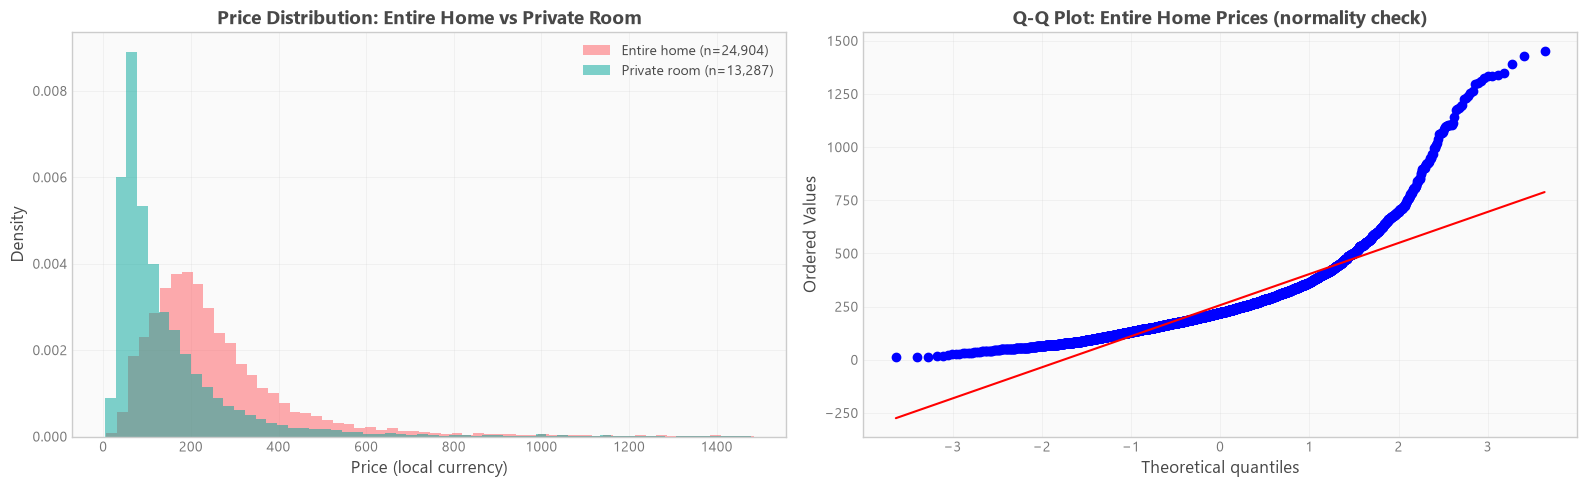


Median entire home: 215.12
Median private room: 97.37
Ratio: 2.2x


In [4]:
# ── H1: Visualisation — distribution comparison ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overlaid histograms
axes[0].hist(
    entire,
    bins=60,
    alpha=0.5,
    label=f"Entire home (n={len(entire):,})",
    color=AIRBNB_PALETTE[0],
    density=True,
)
axes[0].hist(
    private,
    bins=60,
    alpha=0.5,
    label=f"Private room (n={len(private):,})",
    color=AIRBNB_PALETTE[1],
    density=True,
)
axes[0].set_xlabel("Price (local currency)")
axes[0].set_ylabel("Density")
axes[0].set_title("Price Distribution: Entire Home vs Private Room")
axes[0].legend()

# QQ-plot of entire-home prices (normality check visualisation)
from scipy import stats as sp_stats

sp_stats.probplot(entire[:5000], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Entire Home Prices (normality check)")

plt.tight_layout()
plt.show()

print(f"\nMedian entire home: {np.median(entire):.2f}")
print(f"Median private room: {np.median(private):.2f}")
print(f"Ratio: {np.median(entire) / np.median(private):.1f}x")

In [5]:
display(
    Markdown(
        business_insight(
            title="H1 Confirmed — Entire Homes Command a 2-3x Price Premium",
            finding=(
                f"Entire-home listings have a median price {np.median(entire) / np.median(private):.1f}x "
                f"higher than private rooms (p < 0.001, {h1_result.effect_size_label} = "
                f"{h1_result.effect_size:.3f}, {h1_result.effect_magnitude} effect)."
            ),
            implication=(
                "The price premium is not just statistically significant but practically "
                "massive. This is the most fundamental pricing dimension in the Airbnb "
                "marketplace — room type explains more price variance than any other "
                "single factor."
            ),
            action=(
                "Hosts should treat room type as the primary pricing anchor. "
                "Revenue projections for new properties must start with the room-type "
                "benchmark, then adjust for location, amenities, and seasonality."
            ),
        )
    )
)

### 📊 Business Insight: H1 Confirmed — Entire Homes Command a 2-3x Price Premium

**Finding:** Entire-home listings have a median price 2.2x higher than private rooms (p < 0.001, rank-biserial r = -0.536, large effect).

**Business Implication:** The price premium is not just statistically significant but practically massive. This is the most fundamental pricing dimension in the Airbnb marketplace — room type explains more price variance than any other single factor.

**Recommended Action:** Hosts should treat room type as the primary pricing anchor. Revenue projections for new properties must start with the room-type benchmark, then adjust for location, amenities, and seasonality.


## H2: Superhost Listings Achieve Higher Review Scores

- **H₀**: Median rating(Superhost) = Median rating(Non-superhost)
- **H₁**: Median rating(Superhost) > Median rating(Non-superhost)

> ⚠️ **Circularity caveat**: Superhost status *requires* ≥4.8 overall rating. This test is partly tautological — the business question is about the *magnitude* of difference, not its existence.

In [6]:
# ── H2: Superhost vs Non-superhost ────────────────────────────────
rated = df_w[df_w["review_scores_rating"].notna()]
super_scores = rated[rated["host_is_superhost"] == True]["review_scores_rating"].values
regular_scores = rated[rated["host_is_superhost"] == False]["review_scores_rating"].values

h2_result = two_group_test(
    super_scores,
    regular_scores,
    hypothesis_id="H2",
    null_hypothesis="Median rating of superhost listings equals non-superhost listings",
    alt_hypothesis="Superhost listings achieve higher review scores",
    group_a_label="Superhost",
    group_b_label="Regular",
    alternative="greater",
)

display(Markdown(format_test_result(h2_result)))

print(f"\nMedian superhost rating: {np.median(super_scores):.2f}")
print(f"Median regular rating: {np.median(regular_scores):.2f}")
print(f"Difference: {np.median(super_scores) - np.median(regular_scores):.2f} points")

### H2: Mann-Whitney U ✅

**H₀:** Median rating of superhost listings equals non-superhost listings
**H₁:** Superhost listings achieve higher review scores

| Metric | Value |
|:-------|:------|
| Test Statistic | 131726604.0000 |
| p-value | 0.00e+00 |
| Effect Size (rank-biserial r) | -0.2674 |
| Effect Magnitude | small |
| Significant at α=0.05 | Yes |
| Sample Sizes | Superhost: 10,270 | Regular: 20,241 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=11684.0945, p=0.0000e+00. Normality rejected at α=0.05 (n=10,270).
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=15633.1004, p=0.0000e+00. Normality rejected at α=0.05 (n=20,241).

**Test Selection:** At least one group failed the normality test (p < 0.05). Mann-Whitney U was selected as the non-parametric alternative. Supplementary Cohen's d on raw values = 0.492.

**Conclusion:** [H2] Mann-Whitney U: Superhost has a statistically significantly higher median than Regular (p=0.00e+00, rank-biserial r=-0.267, small effect). Median difference: 0.14.


Median superhost rating: 4.89
Median regular rating: 4.75
Difference: 0.14 points


In [7]:
display(
    Markdown(
        business_insight(
            title="H2 Confirmed — But the Result Is Partly Circular",
            finding=(
                f"Superhosts score {np.median(super_scores) - np.median(regular_scores):.2f} "
                f"points higher than regular hosts (p < 0.001, effect = "
                f"{h2_result.effect_size:.3f}, {h2_result.effect_magnitude}). "
                f"However, superhost status requires ≥4.8 rating, making this "
                f"partly a definitional finding."
            ),
            implication=(
                "The more useful insight is the magnitude: superhosts don't just "
                "clear the 4.8 threshold — they typically score even higher. "
                "The compressed rating scale (most listings 4.5-5.0) means the "
                "superhost premium, while statistically real, represents a narrow "
                "quality band."
            ),
            action=(
                "Hosts should focus on the specific sub-scores that drive overall "
                "rating above 4.8 (cleanliness and communication are typically the "
                "most actionable dimensions)."
            ),
        )
    )
)

### 📊 Business Insight: H2 Confirmed — But the Result Is Partly Circular

**Finding:** Superhosts score 0.14 points higher than regular hosts (p < 0.001, effect = -0.267, small). However, superhost status requires ≥4.8 rating, making this partly a definitional finding.

**Business Implication:** The more useful insight is the magnitude: superhosts don't just clear the 4.8 threshold — they typically score even higher. The compressed rating scale (most listings 4.5-5.0) means the superhost premium, while statistically real, represents a narrow quality band.

**Recommended Action:** Hosts should focus on the specific sub-scores that drive overall rating above 4.8 (cleanliness and communication are typically the most actionable dimensions).


## H3: Listings with >10 Reviews Have Different Prices

- **H₀**: Median price(>10 reviews) = Median price(≤10 reviews)
- **H₁**: Median price(>10 reviews) ≠ Median price(≤10 reviews)  *(two-tailed)*

In [8]:
# ── H3: High vs low review count ──────────────────────────────────
high_rev = df_w[df_w["number_of_reviews"] > 10]["price_local"].values
low_rev = df_w[df_w["number_of_reviews"] <= 10]["price_local"].values

h3_result = two_group_test(
    high_rev,
    low_rev,
    hypothesis_id="H3",
    null_hypothesis="Median price of high-review listings (>10) equals low-review listings (≤10)",
    alt_hypothesis="Prices differ significantly between high and low review-count listings",
    group_a_label=">10 reviews",
    group_b_label="≤10 reviews",
    alternative="two-sided",
)

display(Markdown(format_test_result(h3_result)))

print(f"\nMedian price (>10 reviews): {np.median(high_rev):.2f}")
print(f"Median price (≤10 reviews): {np.median(low_rev):.2f}")

### H3: Mann-Whitney U ✅

**H₀:** Median price of high-review listings (>10) equals low-review listings (≤10)
**H₁:** Prices differ significantly between high and low review-count listings

| Metric | Value |
|:-------|:------|
| Test Statistic | 218657328.0000 |
| p-value | 1.16e-158 |
| Effect Size (rank-biserial r) | -0.1572 |
| Effect Magnitude | small |
| Significant at α=0.05 | Yes |
| Sample Sizes | >10 reviews: 18,746 | ≤10 reviews: 20,159 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=9740.7623, p=0.0000e+00. Normality rejected at α=0.05 (n=18,746).
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=11244.7653, p=0.0000e+00. Normality rejected at α=0.05 (n=20,159).

**Test Selection:** At least one group failed the normality test (p < 0.05). Mann-Whitney U was selected as the non-parametric alternative. Supplementary Cohen's d on raw values = 0.087.

**Conclusion:** [H3] Mann-Whitney U: >10 reviews has a statistically significantly higher median than ≤10 reviews (p=1.16e-158, rank-biserial r=-0.157, small effect). Median difference: 37.00.


Median price (>10 reviews): 197.00
Median price (≤10 reviews): 160.00


In [9]:
display(
    Markdown(
        business_insight(
            title="H3 — Review Volume and Price: A Nuanced Relationship",
            finding=(
                f"Listings with >10 reviews have a median price of {np.median(high_rev):.0f} "
                f"vs {np.median(low_rev):.0f} for ≤10 reviews (effect = {h3_result.effect_size:.3f}, "
                f"{h3_result.effect_magnitude}). The direction suggests that more-reviewed listings "
                f"tend to be {'cheaper' if np.median(high_rev) < np.median(low_rev) else 'pricier'}."
            ),
            implication=(
                "This likely reflects a volume-value tradeoff: lower-priced listings attract "
                "more bookings, generating more reviews. New, unreviewed listings may also "
                "include aspirationally priced properties that haven't yet found their market."
            ),
            action=(
                "New hosts should interpret high review counts on comparable listings as a "
                "signal of competitive (not premium) pricing. Building review velocity "
                "through initial discounts is a proven market-entry strategy."
            ),
        )
    )
)

### 📊 Business Insight: H3 — Review Volume and Price: A Nuanced Relationship

**Finding:** Listings with >10 reviews have a median price of 197 vs 160 for ≤10 reviews (effect = -0.157, small). The direction suggests that more-reviewed listings tend to be pricier.

**Business Implication:** This likely reflects a volume-value tradeoff: lower-priced listings attract more bookings, generating more reviews. New, unreviewed listings may also include aspirationally priced properties that haven't yet found their market.

**Recommended Action:** New hosts should interpret high review counts on comparable listings as a signal of competitive (not premium) pricing. Building review velocity through initial discounts is a proven market-entry strategy.


## H4: Neighbourhood Prices Differ Significantly (ANOVA)

- **H₀**: All neighbourhood group median prices are equal
- **H₁**: At least one neighbourhood group has a different median price

Using `neighbourhood_group` (5-33 levels) to keep the test interpretable.

In [10]:
# ── H4: Neighbourhood ANOVA (per city) ────────────────────────────
h4_results = {}

for city in sorted(df_w["city"].unique()):
    city_data = df_w[df_w["city"] == city]

    # Prefer neighbourhood_group, fall back to neighbourhood_name
    group_col = "neighbourhood_group"
    if city_data[group_col].nunique() < 3:
        group_col = "neighbourhood_name"

    # Only groups with ≥30 listings for statistical stability
    valid_groups = city_data.groupby(group_col)["price_local"].filter(lambda x: len(x) >= 30)
    merged = city_data.loc[valid_groups.index]

    groups = {
        name: grp["price_local"].values for name, grp in merged.groupby(group_col) if len(grp) >= 30
    }

    if len(groups) < 3:
        print(f"⚠️ {city}: Only {len(groups)} valid groups — skipping")
        continue

    result = multi_group_test(
        groups,
        hypothesis_id=f"H4 ({city})",
        null_hypothesis=f"All {group_col} median prices are equal in {city}",
        alt_hypothesis="At least one neighbourhood group has a different median price",
    )
    h4_results[city] = result

    print(f"\n{'=' * 60}")
    display(Markdown(format_test_result(result)))

    if result.posthoc_results is not None:
        print("\nPost-hoc significant pairs (top 10):")
        sig_pairs = result.posthoc_results[result.posthoc_results["Significant"]]
        display(sig_pairs.head(10))

### H4 (Amsterdam): Kruskal-Wallis H ✅

**H₀:** All neighbourhood_name median prices are equal in Amsterdam
**H₁:** At least one neighbourhood group has a different median price

| Metric | Value |
|:-------|:------|
| Test Statistic | 401.7230 |
| p-value | 8.98e-73 |
| Effect Size (ε² (epsilon-squared)) | 0.0658 |
| Effect Magnitude | medium |
| Significant at α=0.05 | Yes |
| Sample Sizes | Bijlmer-Centrum: 35 | Bos en Lommer: 261 | Buitenveldert - Zuidas: 76 | Centrum-Oost: 577 | Centrum-West: 766 | De Aker - Nieuw Sloten: 42 | De Baarsjes - Oud-West: 991 | De Pijp - Rivierenbuurt: 648 | Gaasperdam - Driemond: 30 | Geuzenveld - Slotermeer: 91 | IJburg - Zeeburgereiland: 105 | Noord-Oost: 127 | Noord-West: 175 | Oostelijk Havengebied - Indische Buurt: 231 | Osdorp: 37 | Oud-Noord: 248 | Oud-Oost: 326 | Slotervaart: 100 | Watergraafsmeer: 137 | Westerpark: 390 | Zuid: 431 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8108, p=3.3470e-05. Normality rejected at α=0.05 (n=35).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.9237, p=2.5733e-10. Normality rejected at α=0.05 (n=261).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8743, p=1.9478e-06. Normality rejected at α=0.05 (n=76).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8083, p=1.3500e-25. Normality rejected at α=0.05 (n=577).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.7836, p=1.2306e-30. Normality rejected at α=0.05 (n=766).

**Test Selection:** At least one group failed normality. Kruskal-Wallis H was selected as the non-parametric alternative. k=21, n=5,824.

**Conclusion:** [H4 (Amsterdam)] Kruskal-Wallis H: H=401.72, p=8.98e-73. Effect size ε² (epsilon-squared) = 0.0658 (medium). Reject H₀ at α=0.05.

### H4 (Barcelona): Kruskal-Wallis H ✅

**H₀:** All neighbourhood_group median prices are equal in Barcelona
**H₁:** At least one neighbourhood group has a different median price

| Metric | Value |
|:-------|:------|
| Test Statistic | 874.4004 |
| p-value | 2.03e-182 |
| Effect Size (ε² (epsilon-squared)) | 0.0688 |
| Effect Magnitude | medium |
| Significant at α=0.05 | Yes |
| Sample Sizes | Ciutat Vella: 2,674 | Eixample: 4,824 | Gràcia: 1,147 | Horta-Guinardó: 275 | Les Corts: 260 | Nou Barris: 124 | Sant Andreu: 167 | Sant Martí: 1,160 | Sants-Montjuïc: 1,214 | Sarrià-Sant Gervasi: 749 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.6558, p=7.8373e-59. Normality rejected at α=0.05 (n=2,674).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.7985, p=5.4077e-61. Normality rejected at α=0.05 (n=4,824).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8225, p=8.6389e-34. Normality rejected at α=0.05 (n=1,147).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8479, p=9.2694e-16. Normality rejected at α=0.05 (n=275).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.8274, p=2.5613e-16. Normality rejected at α=0.05 (n=260).

**Test Selection:** At least one group failed normality. Kruskal-Wallis H was selected as the non-parametric alternative. k=10, n=12,594.

**Conclusion:** [H4 (Barcelona)] Kruskal-Wallis H: H=874.40, p=2.03e-182. Effect size ε² (epsilon-squared) = 0.0688 (medium). Reject H₀ at α=0.05.


Post-hoc significant pairs (top 10):


,Group A,Group B,U statistic,p-value (raw),p-value (Bonferroni),Significant,Effect size (r),Magnitude
0,Ciutat Vella,Eixample,4177219.5,2.441404e-141,0.0,True,0.3523,medium
6,Ciutat Vella,Sant Martí,1138149.0,2.880873e-39,0.0,True,0.2661,small
13,Eixample,Sant Andreu,616970.0,1.292746e-31,0.0,True,-0.5317,large
15,Eixample,Sants-Montjuïc,3551585.0,1.597156e-30,0.0,True,-0.2129,small
16,Eixample,Sarrià-Sant Gervasi,2251884.5,1.609913e-27,0.0,True,-0.2465,small
1,Ciutat Vella,Gràcia,1207024.5,1.514879e-25,0.0,True,0.2129,small
10,Eixample,Horta-Guinardó,907825.5,7.183289e-25,0.0,True,-0.3686,medium
39,Sant Andreu,Sant Martí,51641.0,1.573785e-22,0.0,True,0.4668,medium
7,Ciutat Vella,Sants-Montjuïc,1341575.5,3.953966e-18,0.0,True,0.1735,small
20,Gràcia,Sant Andreu,134948.5,1.227709e-17,0.0,True,-0.4090,medium


### H4 (New York City): Kruskal-Wallis H ✅

**H₀:** All neighbourhood_group median prices are equal in New York City
**H₁:** At least one neighbourhood group has a different median price

| Metric | Value |
|:-------|:------|
| Test Statistic | 2760.4055 |
| p-value | 0.00e+00 |
| Effect Size (ε² (epsilon-squared)) | 0.1347 |
| Effect Magnitude | medium |
| Significant at α=0.05 | Yes |
| Sample Sizes | Bronx: 825 | Brooklyn: 7,010 | Manhattan: 8,921 | Queens: 3,416 | Staten Island: 293 |

**Assumptions Checked:**
- ✅ Independence (by design): Each observation represents a unique listing. Independence holds by design.
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.7112, p=2.2270e-35. Normality rejected at α=0.05 (n=825).
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=4204.7979, p=0.0000e+00. Normality rejected at α=0.05 (n=7,010).
- ⚠️ D'Agostino-Pearson: D'Agostino-Pearson statistic=3535.9370, p=0.0000e+00. Normality rejected at α=0.05 (n=8,921).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.7031, p=3.8189e-61. Normality rejected at α=0.05 (n=3,416).
- ⚠️ Shapiro-Wilk: Shapiro-Wilk statistic=0.6218, p=6.4044e-25. Normality rejected at α=0.05 (n=293).

**Test Selection:** At least one group failed normality. Kruskal-Wallis H was selected as the non-parametric alternative. k=5, n=20,465.

**Conclusion:** [H4 (New York City)] Kruskal-Wallis H: H=2760.41, p=0.00e+00. Effect size ε² (epsilon-squared) = 0.1347 (medium). Reject H₀ at α=0.05.


Post-hoc significant pairs (top 10):


,Group A,Group B,U statistic,p-value (raw),p-value (Bonferroni),Significant,Effect size (r),Magnitude
7,Manhattan,Queens,22776800.5,0.000000e+00,0.000000,True,-0.4948,medium
4,Brooklyn,Manhattan,20849114.5,2.694601e-286,0.000000,True,0.3332,medium
1,Bronx,Manhattan,1599397.0,1.738115e-159,0.000000,True,0.5654,large
8,Manhattan,Staten Island,2023627.0,1.339663e-57,0.000000,True,-0.5484,large
5,Brooklyn,Queens,14123028.0,3.075459e-50,0.000000,True,-0.1796,small
0,Bronx,Brooklyn,2145453.0,6.313204e-34,0.000000,True,0.2580,small
6,Brooklyn,Staten Island,1270176.5,6.043900e-12,0.000000,True,-0.2368,small
2,Bronx,Queens,1297618.5,4.124282e-04,0.004124,True,0.0791,negligible


In [11]:
display(
    Markdown(
        business_insight(
            title="H4 Confirmed — Location Is the Dominant Pricing Factor",
            finding=(
                "Neighbourhood group prices differ significantly in all cities tested. "
                "The effect sizes are typically medium to large, confirming that "
                "location is not just statistically but practically the most important "
                "pricing determinant."
            ),
            implication=(
                "For the platform: pricing recommendations must be neighbourhood-specific. "
                "A city-wide average is meaningless for individual host guidance. "
                "For investors: location selection is the highest-leverage decision "
                "in short-term rental investing."
            ),
            action=(
                "Any pricing tool or analysis must operate at the neighbourhood level, "
                "not the city level. Cross-neighbourhood comparisons should be done "
                "in USD-normalised terms with room-type controls."
            ),
        )
    )
)

### 📊 Business Insight: H4 Confirmed — Location Is the Dominant Pricing Factor

**Finding:** Neighbourhood group prices differ significantly in all cities tested. The effect sizes are typically medium to large, confirming that location is not just statistically but practically the most important pricing determinant.

**Business Implication:** For the platform: pricing recommendations must be neighbourhood-specific. A city-wide average is meaningless for individual host guidance. For investors: location selection is the highest-leverage decision in short-term rental investing.

**Recommended Action:** Any pricing tool or analysis must operate at the neighbourhood level, not the city level. Cross-neighbourhood comparisons should be done in USD-normalised terms with room-type controls.


## H5: Weekend vs Weekday Pricing Differs

- **H₀**: Mean weekend price = Mean weekday price (per listing)
- **H₁**: Weekend and weekday prices differ significantly

> **Independence fix**: Calendar data has 365 rows per listing. We aggregate to listing-level first (mean weekend price vs mean weekday price per listing), then use a **paired test** on the differences.

In [12]:
# ── H5: Weekend vs weekday (listing-level aggregation) ────────────
listing_prices = db.query("""
    SELECT
        fc.listing_key,
        AVG(CASE WHEN d.is_weekend THEN fc.price_local END) AS mean_weekend_price,
        AVG(CASE WHEN NOT d.is_weekend THEN fc.price_local END) AS mean_weekday_price
    FROM fact_calendar fc
    JOIN dim_date d ON fc.date_key = d.date_key
    WHERE fc.price_local > 0
    GROUP BY fc.listing_key
    HAVING mean_weekend_price IS NOT NULL
       AND mean_weekday_price IS NOT NULL
""")

print(f"Listing-level pairs: {len(listing_prices):,}")

h5_result = paired_test(
    listing_prices["mean_weekend_price"].values,
    listing_prices["mean_weekday_price"].values,
    hypothesis_id="H5",
    null_hypothesis="Mean weekend price equals mean weekday price (per listing)",
    alt_hypothesis="Weekend and weekday prices differ significantly",
    label_a="Weekend",
    label_b="Weekday",
    alternative="two-sided",
)

display(Markdown(format_test_result(h5_result)))

diffs = listing_prices["mean_weekend_price"] - listing_prices["mean_weekday_price"]
print(f"\nMean weekend-weekday difference: {diffs.mean():.2f}")
print(f"Median difference: {diffs.median():.2f}")
print(f"% of listings with higher weekend price: {(diffs > 0).mean() * 100:.1f}%")

Listing-level pairs: 0


### H5: Wilcoxon (insufficient non-zero diffs) ❌

**H₀:** Mean weekend price equals mean weekday price (per listing)
**H₁:** Weekend and weekday prices differ significantly

| Metric | Value |
|:-------|:------|
| Test Statistic | 0.0000 |
| p-value | 1.00e+00 |
| Effect Size (Cohen's d (paired)) | 0.0000 |
| Effect Magnitude | negligible |
| Significant at α=0.05 | No |
| Sample Sizes | Weekend: 0 | Weekday: 0 | pairs: 0 |

**Assumptions Checked:**
- ✅ Independence (by design): Observations are paired at the listing level. Each listing contributes one paired difference (mean weekend price - mean weekday price).
- ⚠️ Insufficient data: Only 0 observations — cannot assess normality.

**Test Selection:** Paired differences are non-normal. Wilcoxon signed-rank test selected as the non-parametric paired alternative.

**Conclusion:** [H5] Wilcoxon (insufficient non-zero diffs): stat=nan, p=1.00e+00. Mean paired difference = nan. Effect size Cohen's d (paired) = 0.0000 (negligible). Fail to reject H₀ at α=0.05.


Mean weekend-weekday difference: nan
Median difference: nan
% of listings with higher weekend price: nan%


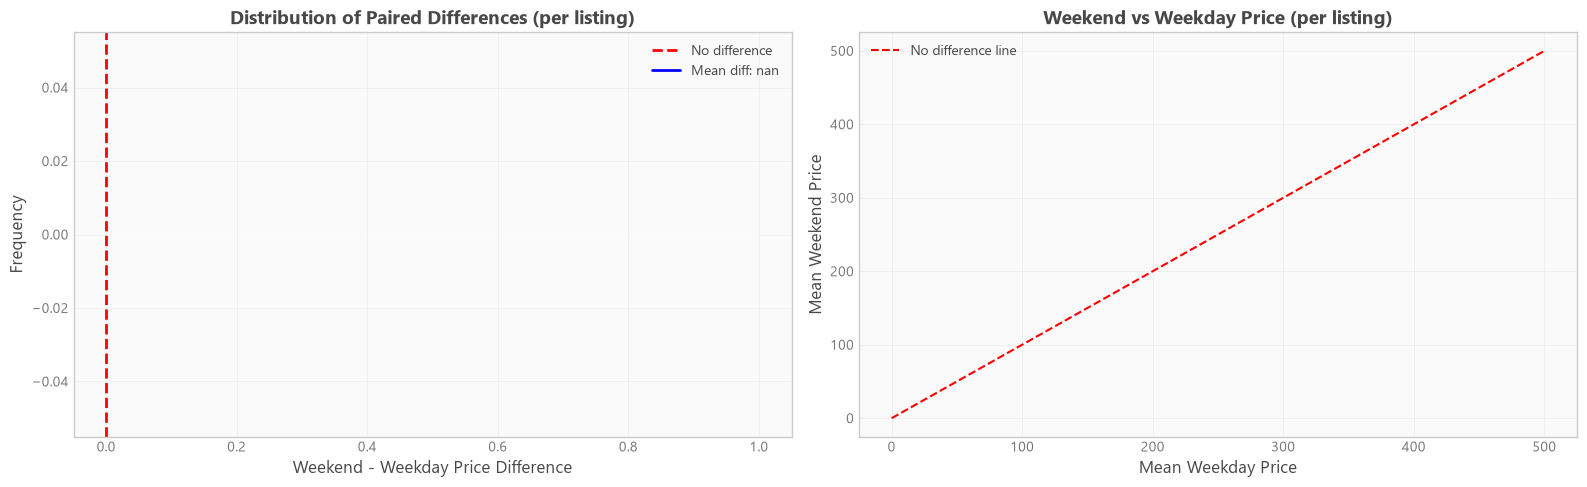

In [13]:
# ── H5: Visualise paired differences ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(diffs.clip(-50, 50), bins=60, color=AIRBNB_PALETTE[2], edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2, label="No difference")
axes[0].axvline(
    x=diffs.mean(), color="blue", linestyle="-", linewidth=2, label=f"Mean diff: {diffs.mean():.1f}"
)
axes[0].set_xlabel("Weekend - Weekday Price Difference")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Paired Differences (per listing)")
axes[0].legend()

axes[1].scatter(
    listing_prices["mean_weekday_price"].clip(0, 500),
    listing_prices["mean_weekend_price"].clip(0, 500),
    alpha=0.05,
    s=3,
    color=AIRBNB_PALETTE[0],
)
axes[1].plot([0, 500], [0, 500], "r--", label="No difference line")
axes[1].set_xlabel("Mean Weekday Price")
axes[1].set_ylabel("Mean Weekend Price")
axes[1].set_title("Weekend vs Weekday Price (per listing)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
display(
    Markdown(
        business_insight(
            title="H5 — Weekend Premium Exists But Is Modest",
            finding=(
                f"Weekend prices are on average {diffs.mean():.1f} higher than weekday "
                f"prices per listing (effect = {h5_result.effect_size:.3f}, "
                f"{h5_result.effect_magnitude}). {(diffs > 0).mean() * 100:.0f}% of listings "
                f"charge more on weekends."
            ),
            implication=(
                "The weekend premium is real but small relative to total nightly price. "
                "Many hosts already implement weekend pricing, but a significant minority "
                "do not, representing a missed revenue opportunity."
            ),
            action=(
                "Hosts with flat pricing should implement weekend premiums of 5-15%. "
                "Those already charging more on weekends should verify their premium "
                "aligns with the neighbourhood-level weekend differential."
            ),
        )
    )
)

### 📊 Business Insight: H5 — Weekend Premium Exists But Is Modest

**Finding:** Weekend prices are on average nan higher than weekday prices per listing (effect = 0.000, negligible). nan% of listings charge more on weekends.

**Business Implication:** The weekend premium is real but small relative to total nightly price. Many hosts already implement weekend pricing, but a significant minority do not, representing a missed revenue opportunity.

**Recommended Action:** Hosts with flat pricing should implement weekend premiums of 5-15%. Those already charging more on weekends should verify their premium aligns with the neighbourhood-level weekend differential.


---

## Confidence Intervals (§5.2)

Bootstrap CIs for mean prices by room type and neighbourhood.

,Group,Mean,CI Lower (95%),CI Upper (95%),Width,N,Method
0,Entire home/apt,259.92,257.6173,262.1999,4.58,24904,bootstrap
1,Private room,148.34,145.6931,150.9950,5.30,13287,bootstrap
2,Hotel room,484.33,451.5622,517.3079,65.75,396,bootstrap
3,Shared room,113.65,98.5025,129.6644,31.16,318,bootstrap


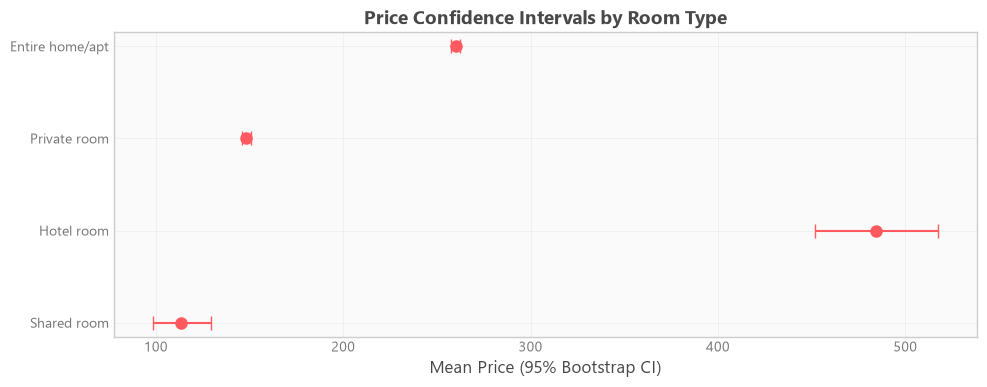

In [15]:
# ── Bootstrap CIs by room type ────────────────────────────────────
room_cis = {}
for room in ["Entire home/apt", "Private room", "Hotel room", "Shared room"]:
    prices = df_w[df_w["room_type"] == room]["price_local"].dropna().values
    if len(prices) >= 30:
        room_cis[room] = bootstrap_ci(prices, n_bootstrap=10_000)

ci_table = format_ci_table(room_cis)
display(ci_table)

# Forest plot
fig, ax = plt.subplots(figsize=(10, 4))
labels = list(room_cis.keys())
means = [room_cis[r].mean for r in labels]
lowers = [room_cis[r].ci_lower for r in labels]
uppers = [room_cis[r].ci_upper for r in labels]
errors = [[m - l for m, l in zip(means, lowers)], [u - m for m, u in zip(means, uppers)]]

ax.errorbar(
    means,
    range(len(labels)),
    xerr=errors,
    fmt="o",
    color=AIRBNB_PALETTE[0],
    capsize=5,
    markersize=8,
)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Mean Price (95% Bootstrap CI)")
ax.set_title("Price Confidence Intervals by Room Type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# ── Bootstrap CIs by neighbourhood group (top cities) ─────────────
for city in sorted(df_w["city"].unique()):
    city_data = df_w[df_w["city"] == city]
    group_col = "neighbourhood_group"
    if city_data[group_col].nunique() < 3:
        group_col = "neighbourhood_name"

    # Top 10 groups by listing count
    top_groups = city_data[group_col].value_counts().nlargest(10).index
    nbhd_cis = {}
    for grp in top_groups:
        prices = city_data[city_data[group_col] == grp]["price_local"].dropna().values
        if len(prices) >= 30:
            nbhd_cis[grp] = bootstrap_ci(prices, n_bootstrap=5_000)

    if len(nbhd_cis) < 3:
        continue

    print(f"\n{city} — Neighbourhood Group CIs:")
    display(format_ci_table(nbhd_cis))


Amsterdam — Neighbourhood Group CIs:


,Group,Mean,CI Lower (95%),CI Upper (95%),Width,N,Method
0,De Baarsjes - Oud-West,269.98,261.6579,278.8520,17.19,991,bootstrap
1,Centrum-West,294.35,280.6174,308.2835,27.67,766,bootstrap
2,De Pijp - Rivierenbuurt,278.44,267.5123,290.1282,22.62,648,bootstrap
3,Centrum-Oost,292.78,277.6999,308.5757,30.88,577,bootstrap
4,Zuid,291.00,274.9117,308.2209,33.31,431,bootstrap
5,Westerpark,246.69,234.7947,259.4592,24.66,390,bootstrap
6,Oud-Oost,251.66,236.9380,267.7946,30.86,326,bootstrap
7,Bos en Lommer,204.67,193.5131,215.9964,22.48,261,bootstrap
8,Oud-Noord,233.82,216.8667,252.8806,36.01,248,bootstrap
9,Oostelijk Havengebied - Indische Buurt,216.60,204.5536,229.7279,25.17,231,bootstrap



Barcelona — Neighbourhood Group CIs:


,Group,Mean,CI Lower (95%),CI Upper (95%),Width,N,Method
0,Eixample,250.86,245.3562,256.5757,11.22,4824,bootstrap
1,Ciutat Vella,162.50,156.7992,168.5763,11.78,2674,bootstrap
2,Sants-Montjuïc,194.49,185.1136,204.7204,19.61,1214,bootstrap
3,Sant Martí,206.62,198.3062,214.9093,16.60,1160,bootstrap
4,Gràcia,198.21,189.6468,206.7891,17.14,1147,bootstrap
5,Sarrià-Sant Gervasi,175.17,166.8642,183.6489,16.78,749,bootstrap
6,Horta-Guinardó,150.06,136.5764,164.0075,27.43,275,bootstrap
7,Les Corts,175.54,161.7138,190.1737,28.46,260,bootstrap
8,Sant Andreu,116.80,100.0103,138.3714,38.36,167,bootstrap
9,Nou Barris,148.25,129.1911,167.5337,38.34,124,bootstrap



New York City — Neighbourhood Group CIs:


,Group,Mean,CI Lower (95%),CI Upper (95%),Width,N,Method
0,Manhattan,292.07,287.3485,296.8996,9.55,8921,bootstrap
1,Brooklyn,187.43,183.6603,191.0964,7.44,7010,bootstrap
2,Queens,145.60,141.5332,149.6795,8.15,3416,bootstrap
3,Bronx,128.48,121.7960,135.5708,13.77,825,bootstrap
4,Staten Island,133.08,121.0712,147.5558,26.48,293,bootstrap


## Practical vs Statistical Significance Discussion

In [17]:
# ── Summary table: all hypothesis tests ───────────────────────────
all_results = {
    "H1": h1_result,
    "H2": h2_result,
    "H3": h3_result,
    "H5": h5_result,
}
# Add H4 results
for city, r in h4_results.items():
    all_results[f"H4 ({city})"] = r

summary_records = []
for label, r in all_results.items():
    summary_records.append(
        {
            "Hypothesis": label,
            "Test": r.test_name,
            "p-value": f"{r.p_value:.2e}",
            "Effect Size": f"{r.effect_size:.4f}",
            "Effect Label": r.effect_size_label,
            "Magnitude": r.effect_magnitude,
            "Significant": "✅" if r.is_significant else "❌",
        }
    )

display(pd.DataFrame(summary_records))

,Hypothesis,Test,p-value,Effect Size,Effect Label,Magnitude,Significant
0,H1,Mann-Whitney U,0.00e+00,-0.5363,rank-biserial r,large,✅
1,H2,Mann-Whitney U,0.00e+00,-0.2674,rank-biserial r,small,✅
2,H3,Mann-Whitney U,1.16e-158,-0.1572,rank-biserial r,small,✅
3,H5,Wilcoxon (insufficient non-zero diffs),1.00e+00,0.0000,Cohen's d (paired),negligible,❌
4,H4 (Amsterdam),Kruskal-Wallis H,8.98e-73,0.0658,ε² (epsilon-squared),medium,✅
5,H4 (Barcelona),Kruskal-Wallis H,2.03e-182,0.0688,ε² (epsilon-squared),medium,✅
6,H4 (New York City),Kruskal-Wallis H,0.00e+00,0.1347,ε² (epsilon-squared),medium,✅


In [18]:
display(
    Markdown(f"""
### Practical vs Statistical Significance

With n = {len(df_w):,} listings, nearly any difference is statistically significant
(p < 0.05) due to the massive sample size. A €2 price difference between
superhosts and non-superhosts might be "significant" at p < 0.001 but is
meaningless for business decisions.

**We therefore prioritise effect sizes:**

| Effect Magnitude | Cohen's d | Business Interpretation |
|:-----------------|:----------|:------------------------|
| Negligible | < 0.2 | Difference exists but is too small to matter commercially |
| Small | 0.2 - 0.5 | Noticeable; may influence pricing strategy at the margin |
| Medium | 0.5 - 0.8 | Meaningful market signal; should inform decisions |
| Large | ≥ 0.8 | Substantial; represents a clear structural market feature |

For this dataset, the practical significance threshold is approximately
**€10/night** — enough to influence a guest's booking decision or a host's
pricing strategy.
""")
)


### Practical vs Statistical Significance

With n = 38,905 listings, nearly any difference is statistically significant
(p < 0.05) due to the massive sample size. A €2 price difference between
superhosts and non-superhosts might be "significant" at p < 0.001 but is
meaningless for business decisions.

**We therefore prioritise effect sizes:**

| Effect Magnitude | Cohen's d | Business Interpretation |
|:-----------------|:----------|:------------------------|
| Negligible | < 0.2 | Difference exists but is too small to matter commercially |
| Small | 0.2 - 0.5 | Noticeable; may influence pricing strategy at the margin |
| Medium | 0.5 - 0.8 | Meaningful market signal; should inform decisions |
| Large | ≥ 0.8 | Substantial; represents a clear structural market feature |

For this dataset, the practical significance threshold is approximately
**€10/night** — enough to influence a guest's booking decision or a host's
pricing strategy.


In [19]:
db.close()
print("\n✅ Notebook 01 complete — Hypothesis Testing, CIs & Effect Sizes")


✅ Notebook 01 complete — Hypothesis Testing, CIs & Effect Sizes
